In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set(font_scale=1.1)

In [8]:
#Data Loading

In [9]:
df = pd.read_csv(r"C:\Users\SAMIKSHA\Desktop\Factory-Reallocation-Optimization\data\Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [10]:
#Data Preview

In [11]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (10194, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  C

In [12]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [13]:
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,8549,717,1338,4,2,542,59,654,3,4,15,15
top,US-2021-155502-CHO-MIL-31000,02-09-2025,07-06-2028,Standard Class,United States,New York City,California,10035,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate
freq,5,62,38,6120,9994,915,2001,263,9844,3253,2137,2137


In [14]:
#Data Cleaning

In [15]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [16]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [17]:
#Finding missing Values

In [18]:
missing = (df.isnull().sum()/len(df))*100

missing.sort_values(ascending=False)

Row ID            0.0
Order ID          0.0
Gross Profit      0.0
Units             0.0
Sales             0.0
Product Name      0.0
Product ID        0.0
Region            0.0
Division          0.0
Postal Code       0.0
State/Province    0.0
City              0.0
Country/Region    0.0
Customer ID       0.0
Ship Mode         0.0
Ship Date         0.0
Order Date        0.0
Cost              0.0
dtype: float64

In [19]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [20]:
print(df[num_cols].isnull().sum())

Row ID          0
Customer ID     0
Sales           0
Units           0
Gross Profit    0
Cost            0
dtype: int64


In [21]:
cat_cols = df.select_dtypes(include=["object"]).columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [22]:
print(df[cat_cols].isnull().sum())

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
dtype: int64


In [23]:
print(df.duplicated().sum())

0


In [24]:
#Conversion of Dates

In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)

df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst =True)

In [26]:
#Finding Lead Time

In [27]:
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date','Ship Date','Lead Time']].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [28]:
#Exploratory Visualization

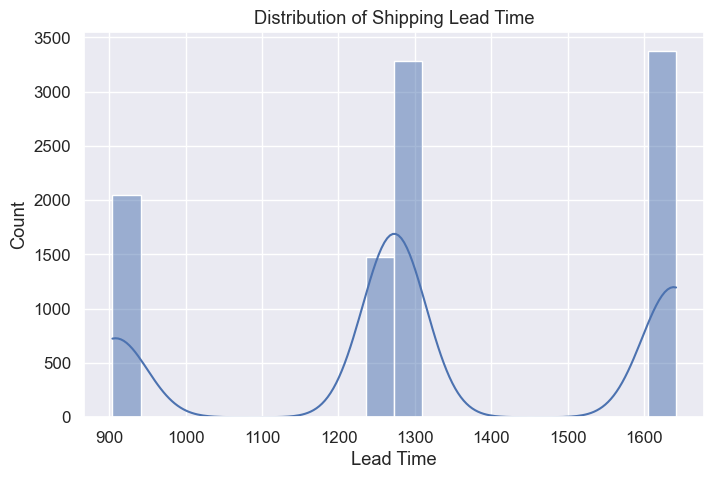

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['Lead Time'], bins=20, kde=True)

plt.title("Distribution of Shipping Lead Time")
plt.show()

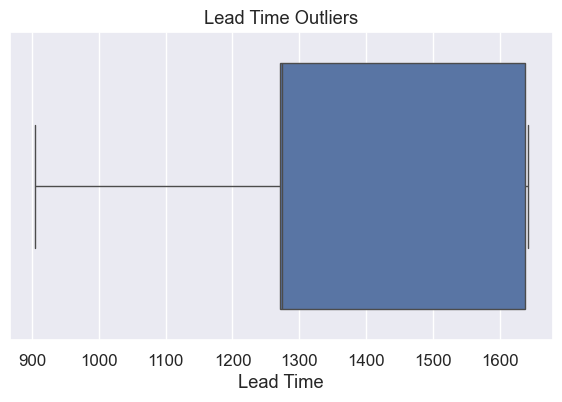

In [30]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df['Lead Time'])

plt.title("Lead Time Outliers")
plt.show()

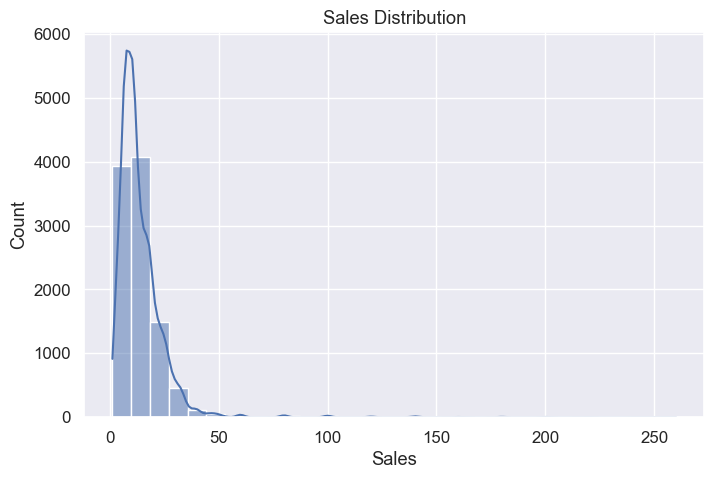

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Sales Distribution")
plt.show()

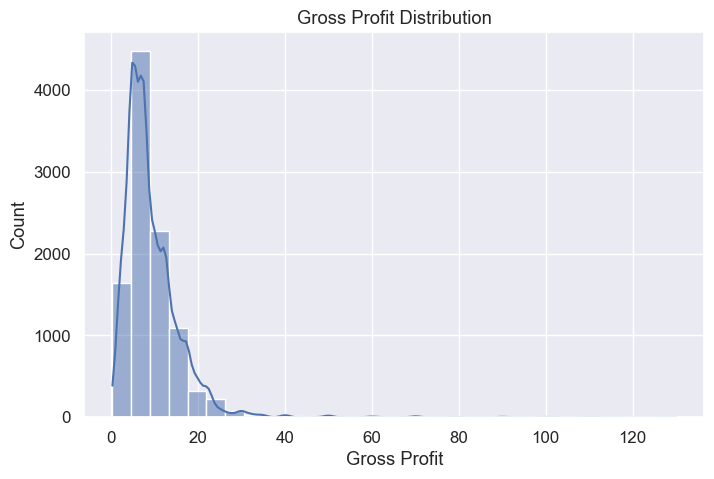

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df['Gross Profit'], bins=30, kde=True)

plt.title("Gross Profit Distribution")
plt.show()

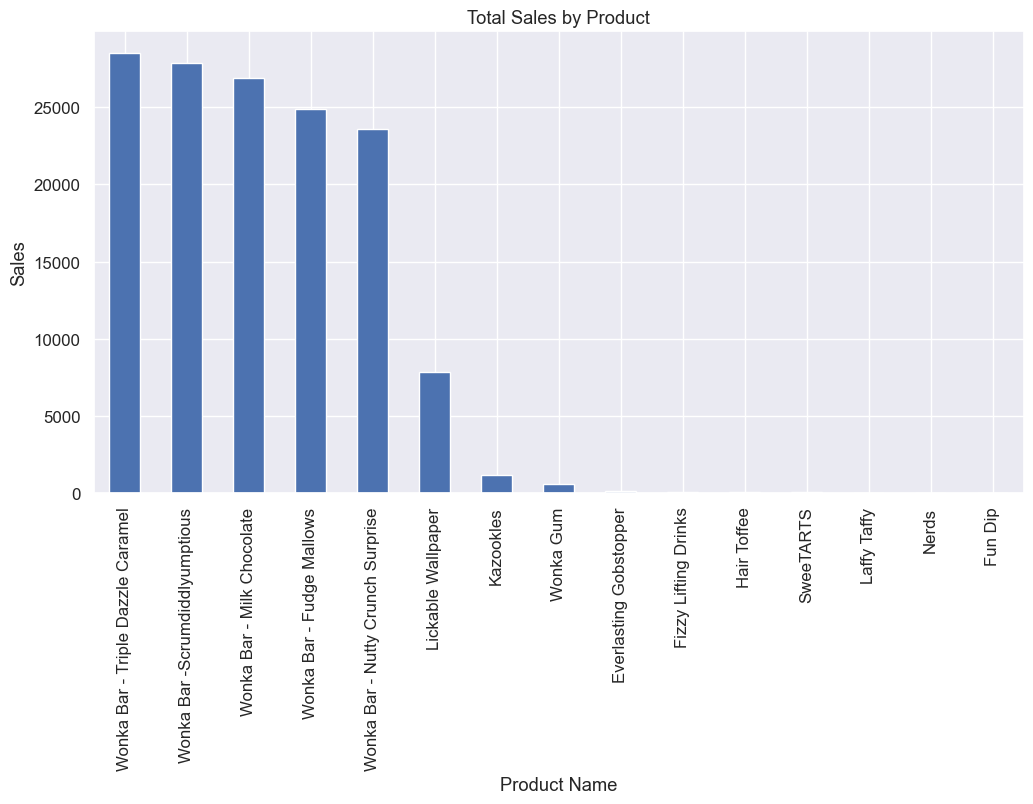

In [33]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Total Sales by Product")

plt.ylabel("Sales")

plt.show()

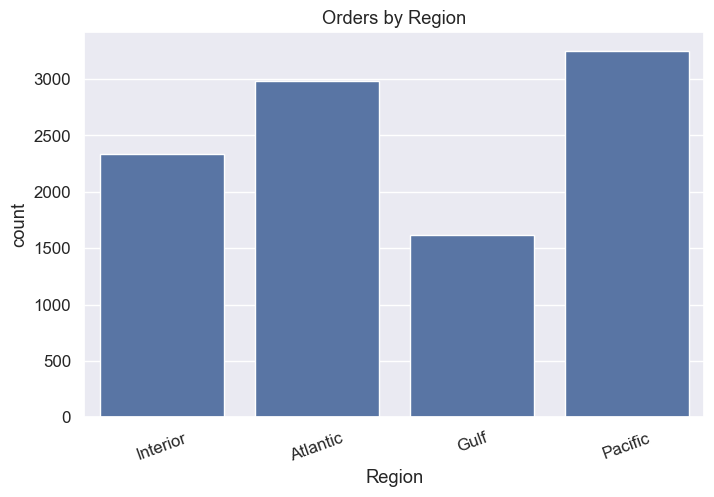

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Region")

plt.title("Orders by Region")

plt.xticks(rotation=20)

plt.show()

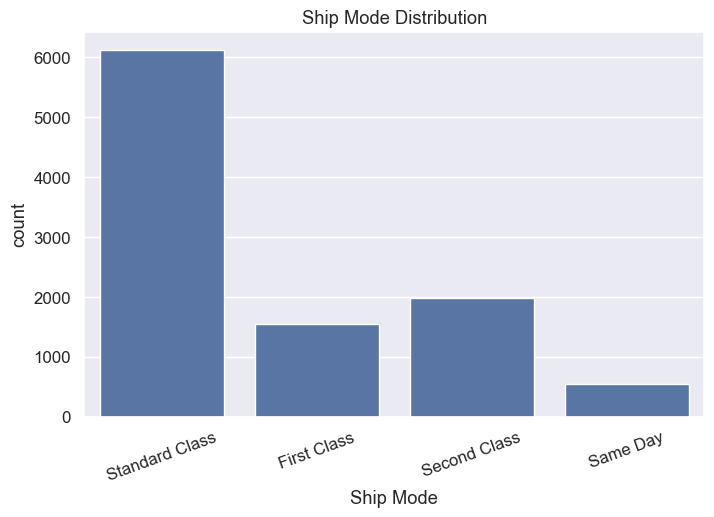

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Ship Mode")

plt.title("Ship Mode Distribution")

plt.xticks(rotation=20)

plt.show()

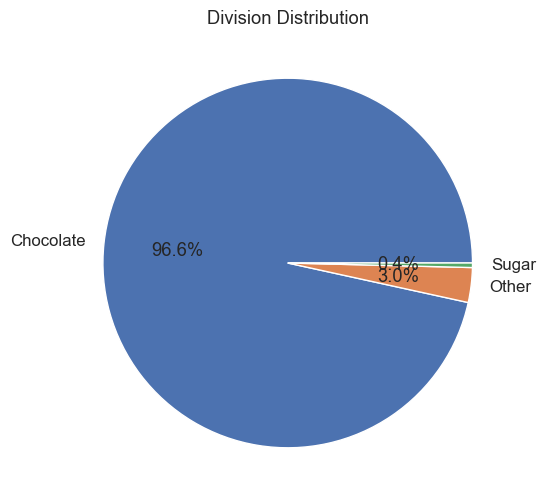

In [36]:
plt.figure(figsize=(6,6))

df['Division'].value_counts().plot(kind='pie',autopct="%1.1f%%")

plt.ylabel("")

plt.title("Division Distribution")

plt.show()

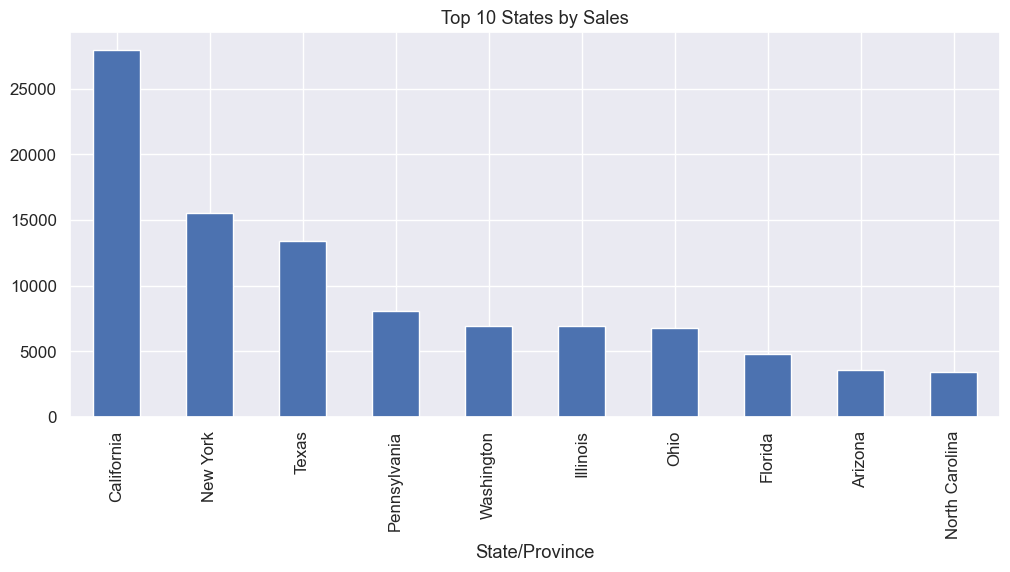

In [37]:
state_sales = df.groupby("State/Province")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

state_sales.plot(kind='bar')

plt.title("Top 10 States by Sales")

plt.show()

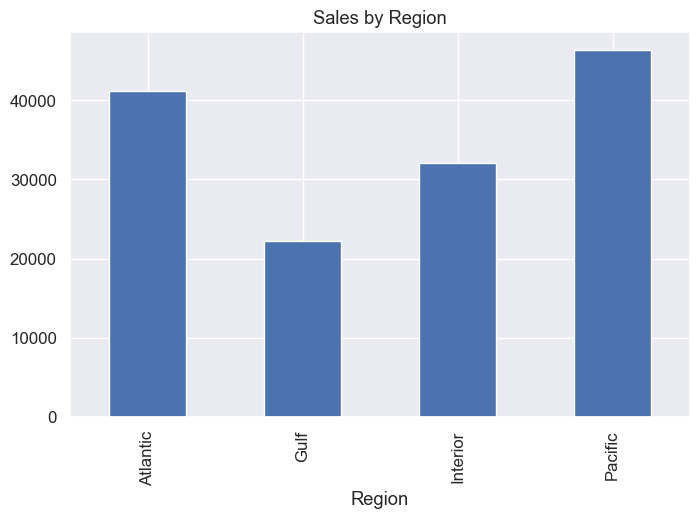

In [38]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")

plt.show()

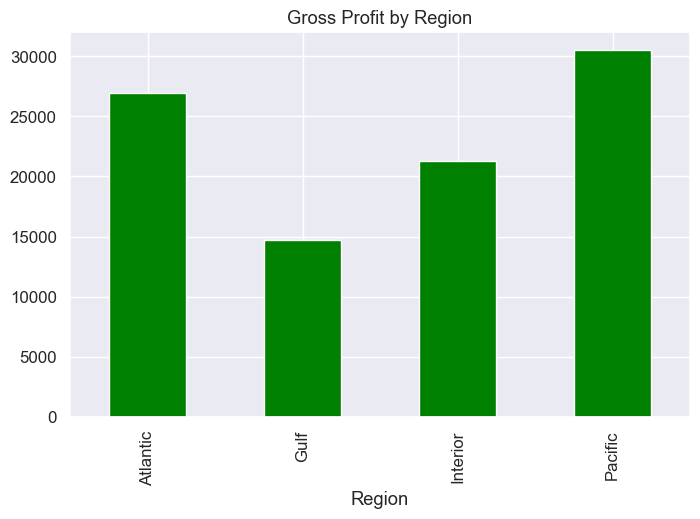

In [39]:
profit = df.groupby("Region")["Gross Profit"].sum()

plt.figure(figsize=(8,5))

profit.plot(kind='bar',color='green')

plt.title("Gross Profit by Region")

plt.show()

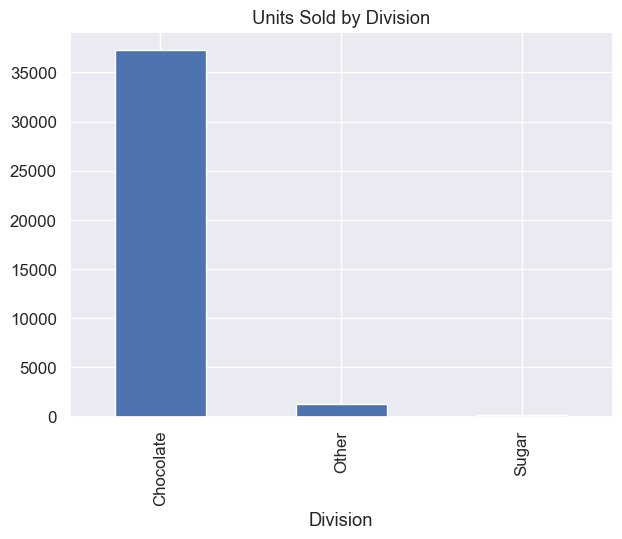

In [40]:
units = df.groupby("Division")["Units"].sum()

plt.figure(figsize=(7,5))

units.plot(kind="bar")

plt.title("Units Sold by Division")

plt.show()

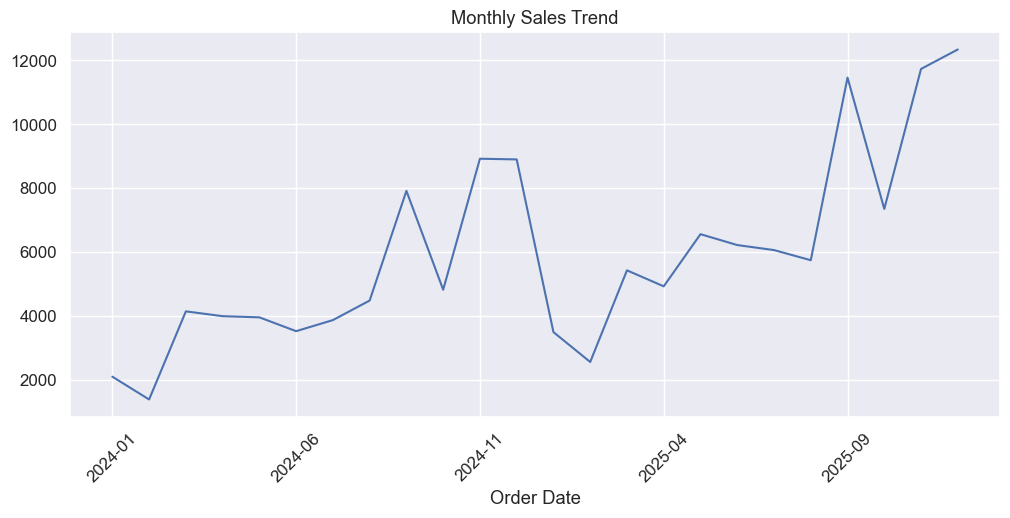

In [41]:
monthly = df.groupby(df['Order Date'].dt.to_period("M"))['Sales'].sum()

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12,5))

monthly.plot()

plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.show()

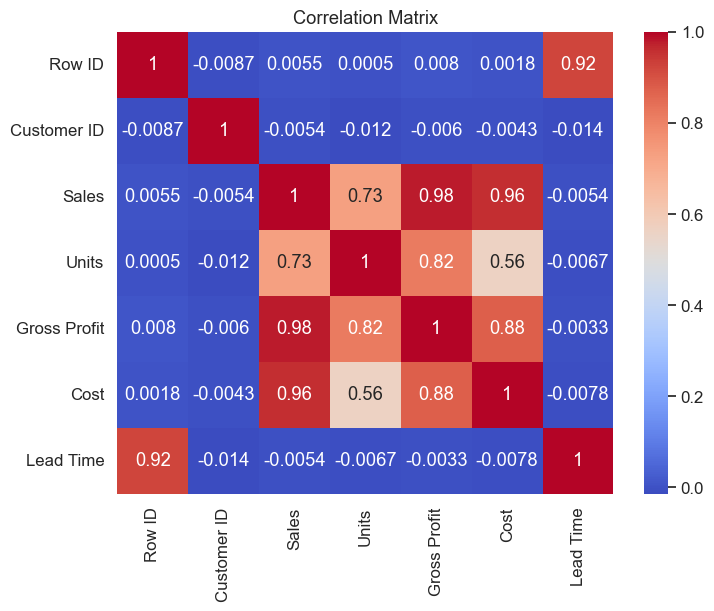

In [42]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

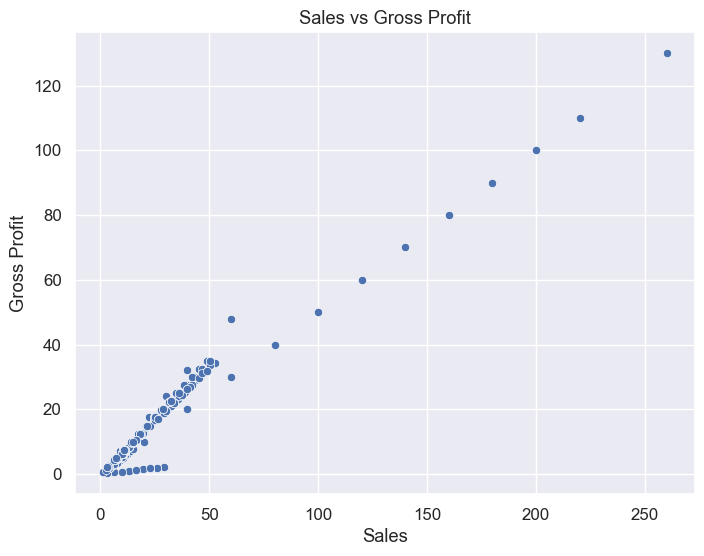

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Gross Profit"
)

plt.title("Sales vs Gross Profit")

plt.show()

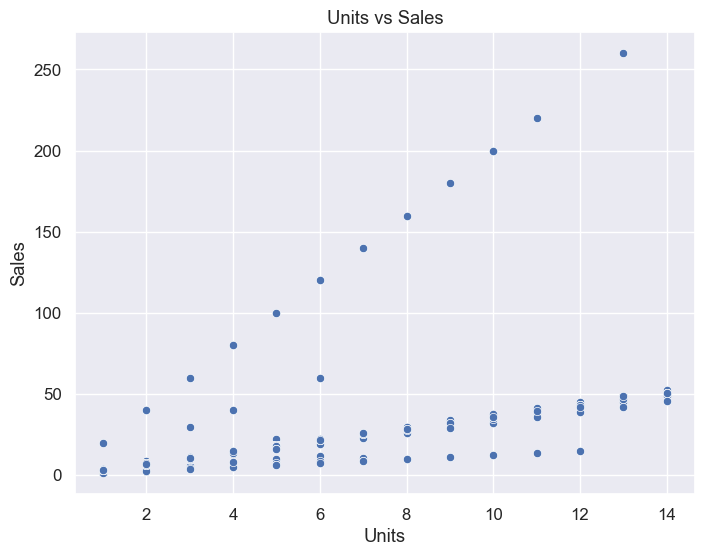

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Units",
    y="Sales"
)

plt.title("Units vs Sales")

plt.show()

In [45]:
df.to_csv("cleaned.csv", index=False)